# Data Exploring

# Exploratory Data Analysis: University Admissions in Turkey (2019–2024)

**Author:** Nikita  Ghosh
**Type:** Real-world Exploratory Data Analysis  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

This project analyzes undergraduate university admission data in Turkey between 2019 and 2024 to understand demand, capacity, student preferences, and placement efficiency.


## Executive Summary

- Student demand has consistently exceeded available quotas across all years.
- Public universities dominate top preference selections and show stronger placement stability.
- Private universities often maintain higher quotas but experience lower placement efficiency.
- Student preferences are highly concentrated, indicating strong selectivity rather than random choice.
- Increasing quotas alone has not significantly improved overall placement outcomes.


## Problem Statement

Turkish universities regularly adjust admission quotas to accommodate growing demand.  
However, it is unclear whether increasing capacity improves placement outcomes or reduces competition.

This analysis aims to:
- Evaluate demand vs capacity trends
- Understand student preference behavior
- Compare public and private university placement efficiency
- Identify structural patterns in competition over time


In [1]:
import pandas  as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10,5)

In [2]:
df = pd.read_csv('01_university_admissions_turkey_2019_2024.csv')

## Dataset Overview

- Time Period: 2019–2024  
- Level: Undergraduate Programs  
- Observations: ~128,000 rows  
- Features: 39 columns  

The dataset includes information on universities, departments, quotas, applications,
placements, and student preference rankings.


In [3]:
df.head()

,program_code,year,university_name,city,university_type,department_name,faculty_name,score_type,scholarship_type,is_undergraduate,...,top_9_pref_count,placed_count,placed_pref_rank_avg,placed_top_1_pref_count,placed_top_3_pref_count,placed_top_10_pref_count,placed_pref_uni_devlet_count,placed_pref_uni_vakif_count,placed_pref_uni_kktc_count,placed_pref_uni_yurt_disi_count
0,106510077,2019,ABDULLAH GÜL ÜNİVERSİTESİ,KAYSERİ,devlet,Bilgisayar Mühendisliği,Mühendislik Fakültesi,SAY,Ücretsiz,True,...,310,62,6.2,10,22,49,802,80,4,2
1,106510077,2020,ABDULLAH GÜL ÜNİVERSİTESİ,KAYSERİ,devlet,Bilgisayar Mühendisliği,Mühendislik Fakültesi,SAY,Ücretsiz,True,...,655,72,7.0,11,19,58,892,109,4,0
2,106510077,2021,ABDULLAH GÜL ÜNİVERSİTESİ,KAYSERİ,devlet,Bilgisayar Mühendisliği,Mühendislik Fakültesi,SAY,Ücretsiz,True,...,655,72,7.1,15,22,54,946,93,5,0
3,106510077,2022,ABDULLAH GÜL ÜNİVERSİTESİ,KAYSERİ,devlet,Bilgisayar Mühendisliği,Mühendislik Fakültesi,SAY,Ücretsiz,True,...,1011,77,7.2,12,21,57,913,104,0,0
4,106510077,2023,ABDULLAH GÜL ÜNİVERSİTESİ,KAYSERİ,devlet,Bilgisayar Mühendisliği,Mühendislik Fakültesi,SAY,Ücretsiz,True,...,714,77,6.5,16,25,61,1090,66,0,0


In [4]:
df.shape

(128352, 39)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128352 entries, 0 to 128351
Data columns (total 39 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   program_code                     128352 non-null  int64  
 1   year                             128352 non-null  int64  
 2   university_name                  128352 non-null  object 
 3   city                             128352 non-null  object 
 4   university_type                  128352 non-null  object 
 5   department_name                  128352 non-null  object 
 6   faculty_name                     127475 non-null  object 
 7   score_type                       128352 non-null  object 
 8   scholarship_type                 128352 non-null  object 
 9   is_undergraduate                 128352 non-null  bool   
 10  all_tags                         70270 non-null   object 
 11  total_quota                      128352 non-null  int64  
 12  to

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
program_code,128352.0,1.545565e+08,6.156625e+07,1.001100e+08,1.049502e+08,1.102103e+08,2.034903e+08,4.096108e+08
year,128352.0,2.021501e+03,1.715442e+00,2.019000e+03,2.020000e+03,2.022000e+03,2.023000e+03,2.024000e+03
total_quota,128352.0,4.748979e+01,1.619614e+02,0.000000e+00,1.300000e+01,4.000000e+01,6.200000e+01,1.845000e+04
total_enrolled,128352.0,4.455723e+01,1.547833e+02,0.000000e+00,1.000000e+01,3.400000e+01,6.200000e+01,1.522600e+04
male,128352.0,2.059012e+01,6.665990e+01,0.000000e+00,4.000000e+00,1.300000e+01,2.600000e+01,6.127000e+03
female,128352.0,2.379671e+01,9.788207e+01,0.000000e+00,4.000000e+00,1.300000e+01,3.200000e+01,9.661000e+03
final_score_012,115482.0,2.913568e+02,6.982880e+01,1.383854e+02,2.386268e+02,2.768995e+02,3.282063e+02,5.554201e+02
final_rank_012,114116.0,7.566999e+05,6.468492e+05,1.800000e+01,2.057695e+05,5.741555e+05,1.238921e+06,2.911151e+06
final_score_018,50153.0,2.669897e+02,4.549083e+01,1.666646e+02,2.328486e+02,2.578125e+02,2.944219e+02,5.221709e+02
final_rank_018,49190.0,1.075540e+06,5.398187e+05,2.850000e+02,6.509090e+05,1.070166e+06,1.487828e+06,2.888549e+06


## Data Quality & Preparation

Before analysis, basic data validation steps were performed:
- Verified data types and year consistency
- Checked for missing values (minimal and non-critical)
- Confirmed no unintended duplicate records

No aggressive cleaning was applied to preserve real-world characteristics of the data.


In [7]:
Col_name = []
VC = []
per = []
for i in df:
    NVC = df[i].isna().sum()    #nvc stands for null value count
    if NVC>0:
        percentage = (NVC / df.shape[0])*100
        Col_name.append(i)
        per.append(percentage)
        VC.append(NVC)
NVP = {'COLUMN NAME':Col_name,"NULL VALUE COUNT":VC,"Percentage":per}      #nvp stands for null percentage count
PNV = pd.DataFrame(NVP)                 POSSIBILITY OF MAP
GENDER DEMOGRAPHICS 

REPORT                          ##PNV is percentage of Null values

In [8]:
PNV

,COLUMN NAME,NULL VALUE COUNT,Percentage
0,faculty_name,877,0.683277
1,all_tags,58082,45.252119
2,final_score_012,12870,10.027113
3,final_rank_012,14236,11.091374
4,final_score_018,78199,60.925424
5,final_rank_018,79162,61.675704
6,avg_obp_012,4125,3.213818
7,avg_obp_018,61090,47.595674
8,placed_pref_rank_avg,3989,3.107860


In [9]:
df['all_tags'].unique()

array(['İngilizce', 'KKTC Uyruklu,İngilizce', 'Burslu', '%50 İndirimli',
       '%50 İndirimli,İÖ', 'Burslu,İÖ', '%25 İndirimli',
       'Ücretli,İngilizce', 'Burslu,İngilizce', '%25 İndirimli,İngilizce',
       'Ücretli', '%50 İndirimli,İngilizce', nan, 'İÖ', 'M.T.O.K.',
       'KKTC Uyruklu', 'Uzaktan Öğretim', 'M.T.O.K.,İÖ', 'İngilizce,İÖ',
       'Ücretli,İÖ', '%25 İndirimli,İÖ', 'Açıköğretim', 'Rusça',
       'Açıköğretim,İngilizce', 'Arapça,Açıköğretim', 'Arapça', 'Almanca',
       'Bulgarca', 'Ermenice', 'Lehçe', 'KKTC Uyruklu,Rusça',
       'Rusça,Uzaktan Öğretim', 'Uzaktan Öğretim,İngilizce', 'İspanyolca',
       'İtalyanca', 'KKTC Uyruklu,İtalyanca', '%75 İndirimli',
       '%75 İndirimli,İngilizce', 'Arapça,M.T.O.K.', '%75 İndirimli,İÖ',
       'Fransızca', 'Burslu,Uzaktan Öğretim',
       '%50 İndirimli,Uzaktan Öğretim', 'Erkek', 'Kız', 'Arapça,Burslu',
       '%50 İndirimli,Arapça', '%25 İndirimli,Arapça',
       'Fransızca,KKTC Uyruklu', 'Almanca,KKTC Uyruklu',
       'Uz

In [10]:
pnv2=PNV[PNV['Percentage']>25]

In [11]:
ctr = []
for i in pnv2.iloc[:,0]:
    ctr.append(i)

In [12]:
for i in ctr:
    df.drop(columns=i,inplace=True)

In [13]:
pnv3=PNV[PNV['Percentage']<25]

In [14]:
list1= []
for i in pnv3.iloc[1:,0]:
    list1.append(i)


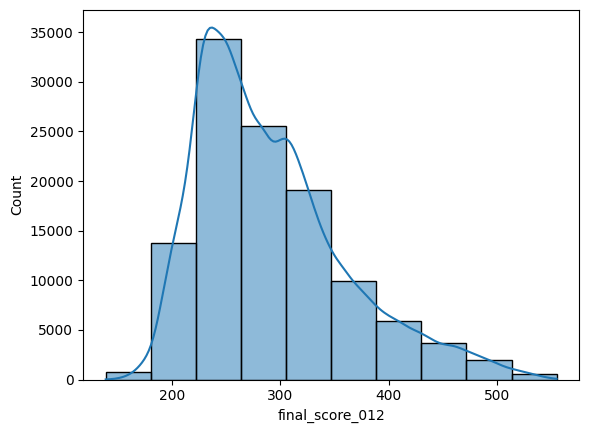

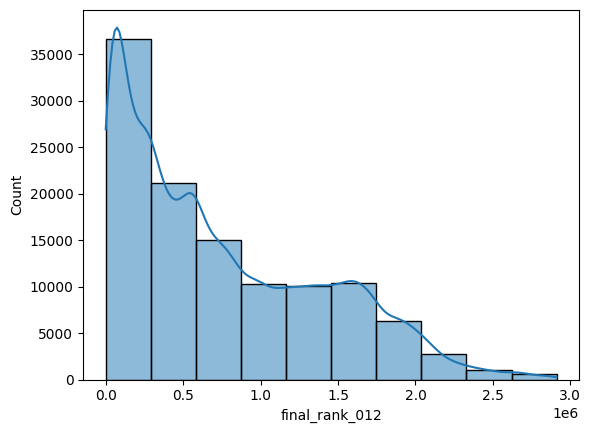

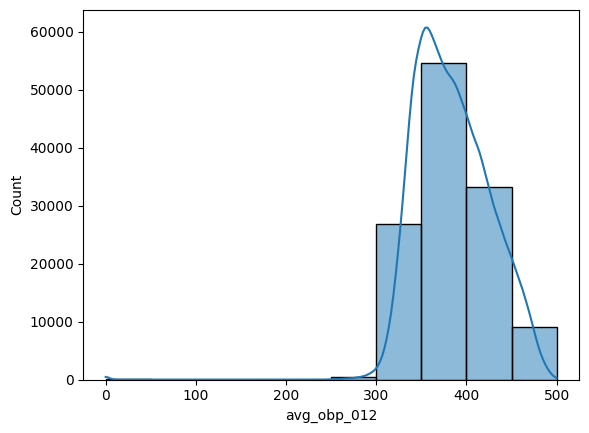

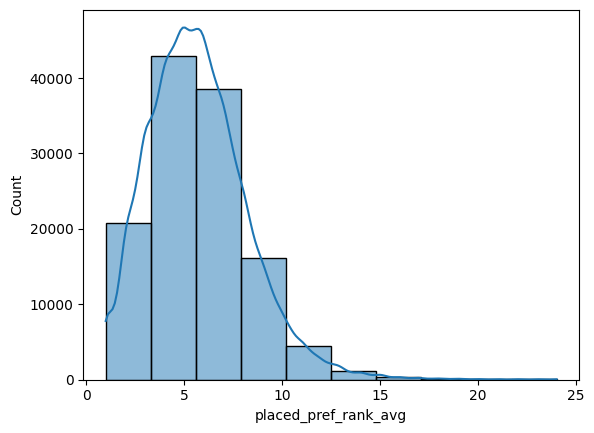

In [16]:
for i in list1:
    sns.histplot(df[i],kde=True,bins=10)
    plt.show()

In [17]:
df['faculty_name'].dropna(inplace=True)

In [18]:
mean_a=df['final_score_012'].mean()
median1=df['final_rank_012'].median()
median2=df['avg_obp_012'].median()
median3=df['placed_pref_rank_avg'].median()

In [19]:
df.fillna({'final_score_012':mean_a,'final_rank_012':median1,'avg_obp_012':median2,'placed_pref_rank_avg':median3},inplace=True)

In [20]:
df.isna().sum()

program_code                         0
year                                 0
university_name                      0
city                                 0
university_type                      0
department_name                      0
faculty_name                       877
score_type                           0
scholarship_type                     0
is_undergraduate                     0
total_quota                          0
total_enrolled                       0
male                                 0
female                               0
final_score_012                      0
final_rank_012                       0
initial_placement_rate               0
not_registered                       0
additional_placement                 0
avg_obp_012                          0
total_preferences                    0
demand_per_quota                     0
avg_preference_rank                  0
top_1_pref_count                     0
top_3_pref_count                     0
top_9_pref_count         

In [21]:
df.dropna(inplace=True)

## here we can fix null values for smooth analysing do in dataset.

In [22]:
df.shape

(127475, 35)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.drop_duplicates(inplace=True)

In [25]:
df.head().T

,0,1,2,3,4
program_code,106510077,106510077,106510077,106510077,106510077
year,2019,2020,2021,2022,2023
university_name,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ
city,KAYSERİ,KAYSERİ,KAYSERİ,KAYSERİ,KAYSERİ
university_type,devlet,devlet,devlet,devlet,devlet
department_name,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği
faculty_name,Mühendislik Fakültesi,Mühendislik Fakültesi,Mühendislik Fakültesi,Mühendislik Fakültesi,Mühendislik Fakültesi
score_type,SAY,SAY,SAY,SAY,SAY
scholarship_type,Ücretsiz,Ücretsiz,Ücretsiz,Ücretsiz,Ücretsiz
is_undergraduate,True,True,True,True,True


### **Outlier Exploration and deletion**

In [26]:
import numpy as np

In [27]:
Q1 = np.percentile(df['total_quota'],25)
Q3 = np.percentile(df['total_quota'],75)

In [28]:
IQR = Q3-Q1 

In [29]:
lower_bound = (Q1 - 1.5 * IQR)
upper_bound = (Q3 + 1.5 * IQR)

In [30]:
df = df[(df['total_quota'] > lower_bound) & (df['total_quota'] < upper_bound)]

# **Exploratory Data Analysis (EDA)**

### **1. Which year has Most Number of Admission's.** 

In [32]:
df['year'].unique()

array([2019, 2020, 2021, 2022, 2023, 2024])

In [33]:
YWA = df.groupby('year')['year'].size().rename('NOA').reset_index()

In [34]:
YWA

,year,NOA
0,2019,21560
1,2020,19868
2,2021,20540
3,2022,20938
4,2023,21473
5,2024,20961


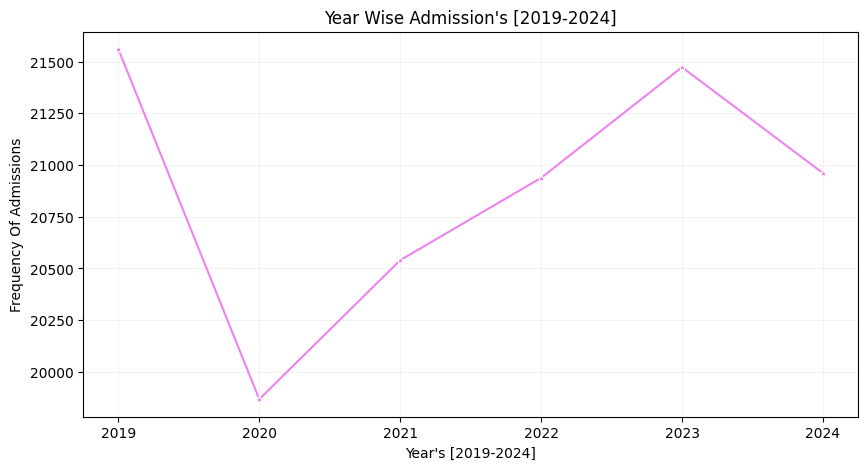

In [35]:
plt.figure(figsize=(10,5))
sns.lineplot(x=YWA['year'],y=YWA['NOA'],color = 'violet',marker='*')
plt.grid(alpha = 0.05,color='black')
plt.title("Year Wise Admission's [2019-2024]")
plt.xlabel("Year's [2019-2024]")
plt.ylabel("Frequency Of Admissions")

plt.show()

## Insight 1 
1. Admission's Happen During the year 2019-2024 we have seen that for 2020 the admission count is pretty low (reason may be cause of pandemic) and for next 2 year's 2021 and 2022 the admission's recorded are average
2. The Admissions Happened Agressively in the year's 2019 and 2023 following 2024.


### Why This Matters
- Universities can use this trend to plan capacity and international recruitment strategies.
- Policymakers can assess how resilient international education is to global disruptions.
- The gradual recovery suggests stability but highlights the need for diversification 
in international student sourcing.


---

### **2. Which University Has Most Number of Admission's.**

In [36]:
UWA = df.groupby('university_name')['university_name'].size().rename('COA').reset_index()
UWA.sort_values(by='COA',ascending=False,inplace=True)

In [37]:
UWA

,university_name,COA
207,İSTANBUL GELİŞİM ÜNİVERSİTESİ,2251
201,İSTANBUL AYDIN ÜNİVERSİTESİ,2050
212,İSTANBUL NİŞANTAŞI ÜNİVERSİTESİ,1960
211,İSTANBUL MEDİPOL ÜNİVERSİTESİ,1894
202,İSTANBUL BEYKENT ÜNİVERSİTESİ,1719
...,...,...
18,ANKARA MÜZİK VE GÜZEL SANATLAR ÜNİVERSİTESİ,6
35,AZERBAYCAN TIP ÜNİVERSİTESİ,5
40,BAKÜ SLAVYAN ÜNİVERSİTESİ,2
136,NAHCİVAN DEVLET ÜNİVERSİTESİ,2


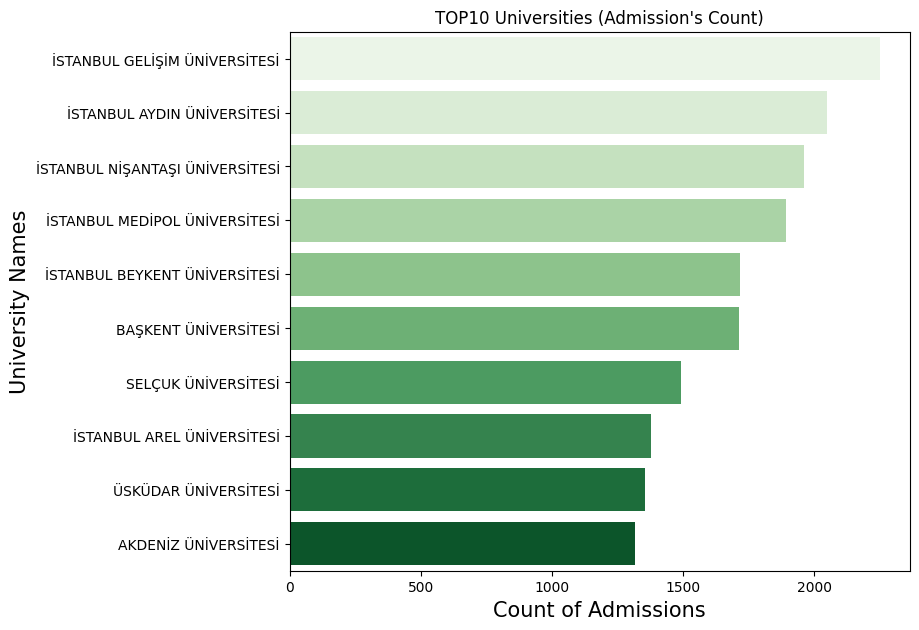

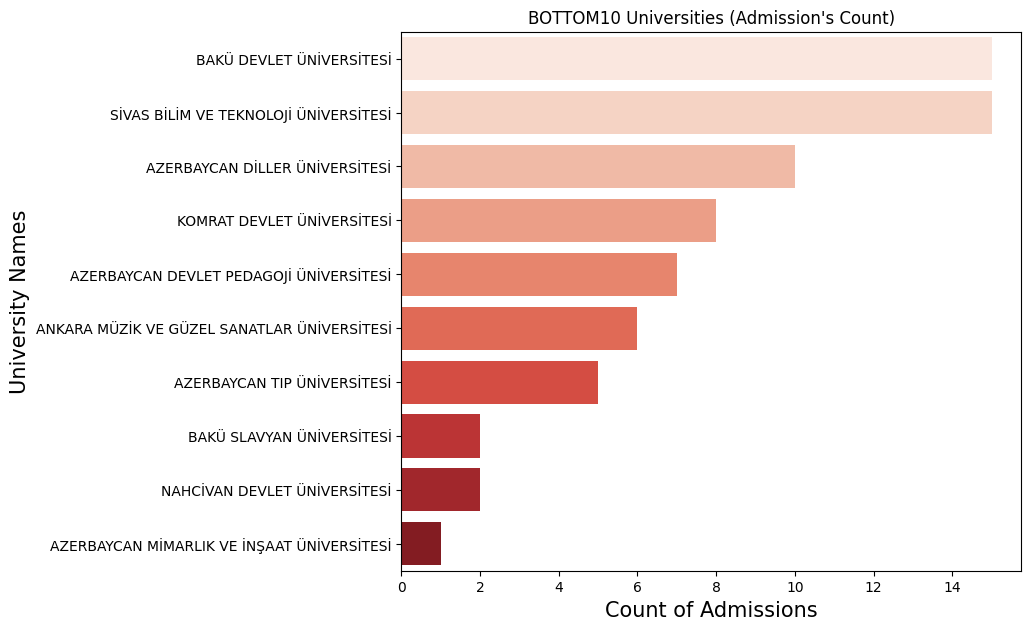

In [38]:
plt.figure(figsize=(8,7))
sns.barplot(y=UWA['university_name'].head(10),x=UWA['COA'].head(10),palette='Greens',hue=UWA['university_name'].head(10))
plt.title("TOP10 Universities (Admission's Count)")
plt.ylabel('University Names',fontdict={'weight':'normal','size':'15'})
plt.xlabel('Count of Admissions',fontdict={'weight':'normal','size':'15'})
plt.show()
plt.figure(figsize=(8,7))
sns.barplot(y=UWA['university_name'].tail(10),x=UWA['COA'].tail(10),palette='Reds',hue=UWA['university_name'].tail(10))
plt.title("BOTTOM10 Universities (Admission's Count)")
plt.ylabel('University Names',fontdict={'weight':'normal','size':'15'})
plt.xlabel('Count of Admissions',fontdict={'weight':'normal','size':'15'})
plt.show()

## Insight 2 
1. 2251 admission happened in İSTANBUL GELİŞİM ÜNİVERSİTESİ recording the top 1 among other universities in Turkish
2. The least Number of Admission Happened are 1 in AZERBAYCAN MİMARLIK VE İNŞAAT ÜNİVERSİTESİ


______________________________________________________________________________________________________________

### **3. which city recorded Highest Number of Admission's**

In [39]:
import matplotlib.image as mpimg

In [40]:
CWA = df.groupby('city')['city'].size().rename('COA').reset_index()

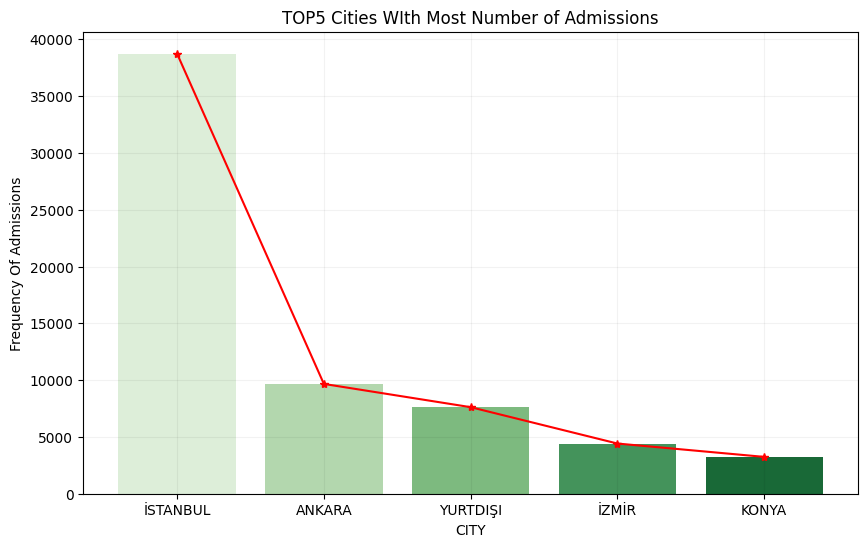

In [42]:
TOP5C = CWA.sort_values(by='COA',ascending=False).head(5)
plt.figure(figsize=(10,6))
sns.barplot(x=TOP5C['city'],y=TOP5C['COA'],palette='Greens',hue=TOP5C['city'])
plt.plot(TOP5C['city'],TOP5C['COA'],color='red',marker='*')
plt.title('TOP5 Cities WIth Most Number of Admissions')
plt.xlabel('CITY')
plt.grid(alpha=0.05,color = 'black')
plt.ylabel('Frequency Of Admissions')
plt.show()

## insight
1. here we can clearly see istanbul city have most admission.likely this city is most prefferd choic for student.
   
2.this citis are suitable for students and likely get best review from students.

### **4. Which university Type has Highest Percentage of Enrollment's**

In [43]:
UTA = df.groupby('university_type')['university_type'].size().rename('COA').reset_index()

In [44]:
UTA

,university_type,COA
0,devlet,70409
1,kktc,6897
2,vakif,47312
3,yurt_disi,722


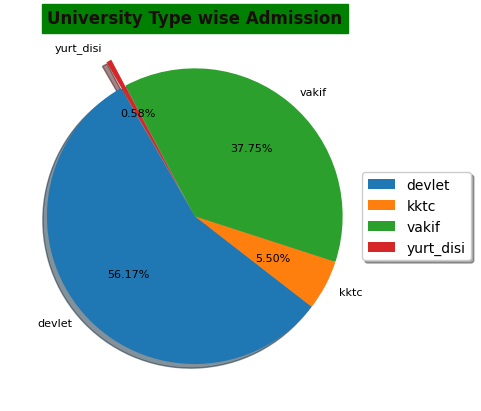

In [45]:
plt.pie(UTA['COA'], labels=UTA['university_type'], autopct='%0.2f%%', startangle=120,
        textprops={'color': 'black','size':8,'fontweight': 'normal'},explode=[0,0,0,0.2],shadow=True)
plt.title('University Type wise Admission',color='#1a0d0d',backgroundcolor='Green',fontweight='bold')
plt.legend(loc='center', bbox_to_anchor=(1.1, 0.5),shadow=True)
plt.show()

## Insight 4 :
1. State Universtiy Type has Highest Number of Enrollments
2. Least Number of Enrollments are for dorm_female univerity type

### **5. Departmenttype/ Program Type Enrollments**

In [46]:
DWA = df.groupby('department_name')['department_name'].size().rename('COA').reset_index()

In [47]:
DWA.sort_values(by='COA',ascending=False,inplace=True)
DWA

,department_name,COA
72,Bilgisayar Programcılığı,2317
657,Çocuk Gelişimi,2220
421,Psikoloji,2007
683,İlk ve Acil Yardım,1956
717,İşletme,1861
...,...,...
38,Azerbaycan Dili ve Edebiyatı,1
10,Aktüerya ve Risk Yönetimi,1
30,Astronomi ve Astrofizik,1
4,Adalet Meslek Yüksekokulu,1


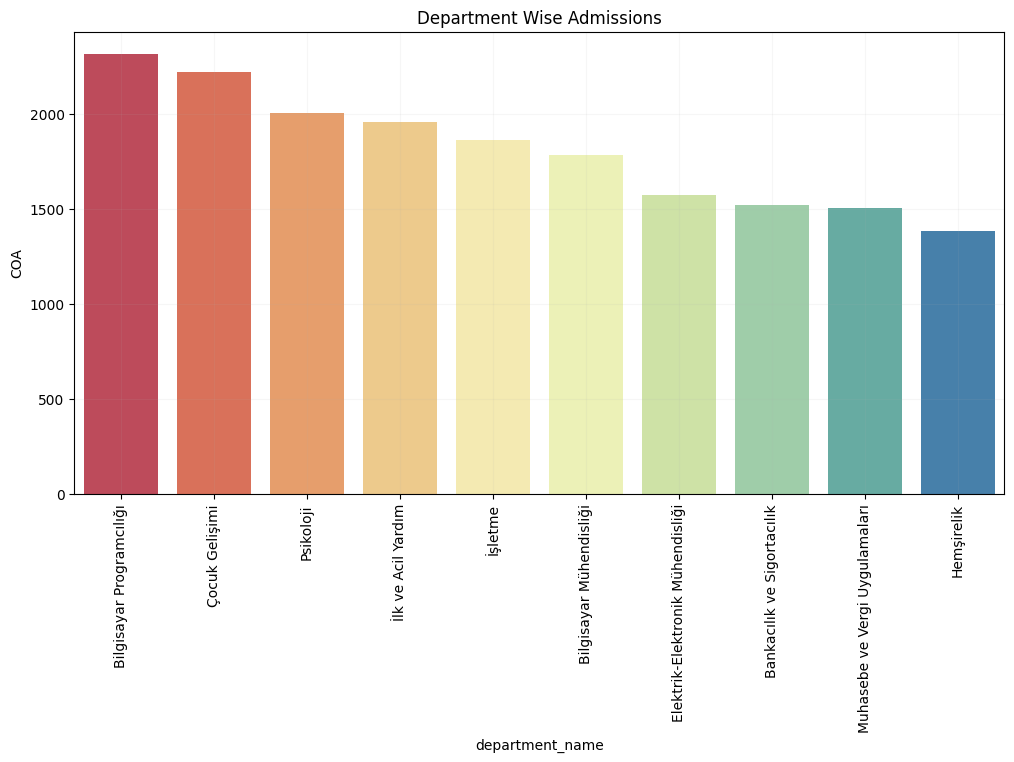

In [48]:
plt.figure(figsize=(12,6))
sns.barplot(x=DWA['department_name'].head(10),y=DWA['COA'].head(10),palette='Spectral',hue=DWA['department_name'].head(10))
plt.title('Department Wise Admissions')
plt.grid(True,alpha=0.1)
plt.xticks(rotation=90)
plt.show()

**Insight 5:**
1. Department Bilgisayar Programcılığı (Computer Programming) has Highest Number of Enrollments with Admissions around 2349 Maybe because of This program being in high demand after the pandamic rise in employment for tech roles.
2. Following Next highest admissions in  Department's child development  and psychology. 

### **6. Scoretype Mostly Used for Admission scores**

In [49]:
df['score_type'].unique()

array(['SAY', 'EA', 'TYT', 'DİL', 'SÖZ'], dtype=object)

1. SAY - COUNT
2. EA  - EA
3. TYT - TYT
4. DİL - LANGUAGE
5. SÖZ - WORD

In [50]:
STA = df.groupby('score_type')['score_type'].size().rename('COST').reset_index()

In [51]:
STA.sort_values(by='COST',ascending=False,inplace=True)

In [52]:
STA

,score_type,COST
4,TYT,58608
2,SAY,29278
1,EA,21626
3,SÖZ,11957
0,DİL,3871


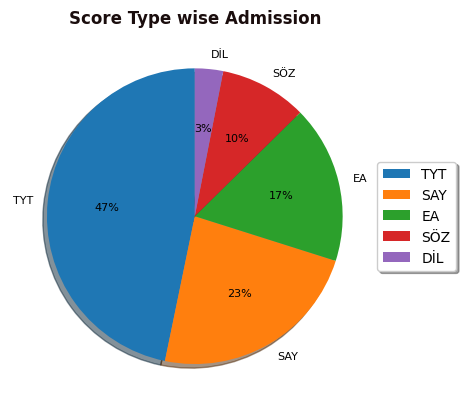

In [53]:
plt.pie(STA['COST'], labels=STA['score_type'], autopct='%0.0f%%', startangle=90,
        textprops={'color': 'black','size':8,'fontweight': 'normal'},shadow=True)
plt.title('Score Type wise Admission',color='#1a0d0d',fontweight='bold')
plt.legend(loc='center', bbox_to_anchor=(1.1, 0.5),shadow=True)
plt.show()

**Insight 6:**
TYT This  Scoretype Mostly Used for Admission score and DİL scoretype is less admission score

**limitations**
here we can  not brifly explain why this result became like this 

### **7. Admission's Happening On scholarshiptype**

In [54]:
df['scholarship_type'].unique()

array(['Ücretsiz', 'Burslu', '%50 İndirimli', 'İÖ-Ücretli',
       '%25 İndirimli', 'Ücretli', 'UÖ-Ücretli', 'UE-Ücretli',
       'AÖ-Ücretli', '%75 İndirimli'], dtype=object)

In [55]:
SCTA = df.groupby('scholarship_type')['scholarship_type'].size().rename('SCTAC').reset_index()
SCTA.sort_values(by  = 'SCTAC',ascending=False,inplace=True)

In [56]:
SCTA

,scholarship_type,SCTAC
8,Ücretsiz,62486
4,Burslu,21747
1,%50 İndirimli,18144
9,İÖ-Ücretli,11018
7,Ücretli,6901
0,%25 İndirimli,2295
2,%75 İndirimli,2006
6,UÖ-Ücretli,730
5,UE-Ücretli,9
3,AÖ-Ücretli,4


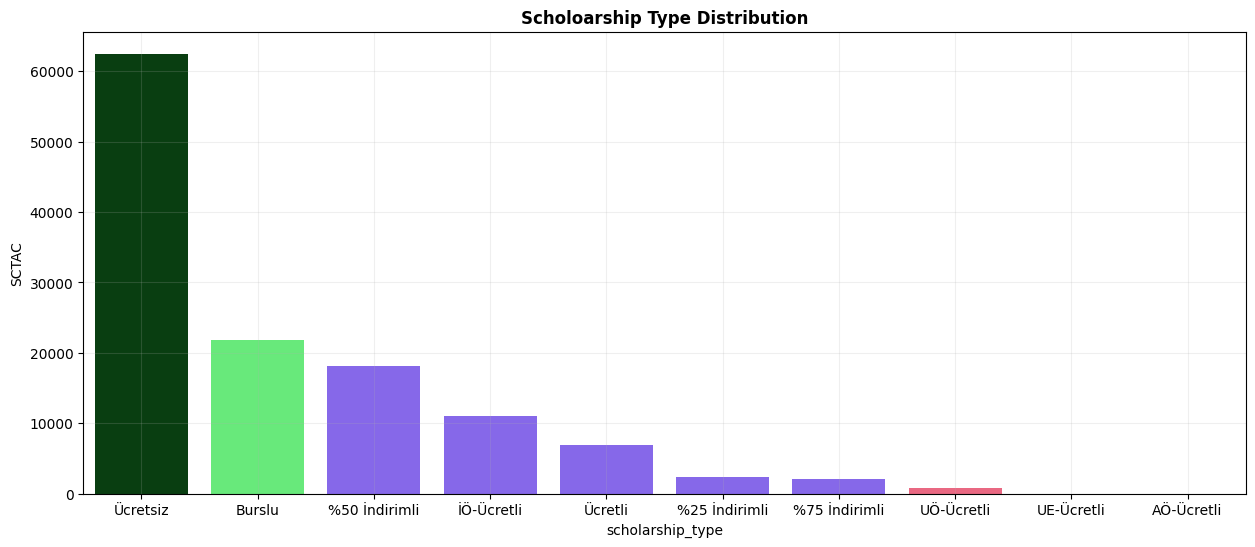

In [57]:
plt.figure(figsize=(15,6))
sns.barplot(x=SCTA['scholarship_type'],y=SCTA['SCTAC'],
            palette=["#00470B","#52FF6C","#7B52FF","#7B52FF","#7B52FF","#7B52FF","#7B52FF","#FF5275","#7B52FF","#7B52FF"]
           ,hue=SCTA['scholarship_type'])
plt.title('Scholoarship Type Distribution',fontdict={'fontweight':'bold'})
plt.grid(True,alpha=0.2)
plt.show()

**Insight 7:**
1.Ücretsiz this scholarshiptype have maximum admission hopefully we all kwon this is free admission thats why student select this scholarshiptype very much.

2.AÖ-Ücretli this scholarship have less admission because this is paid or distance education provide.

-----

### **8. Admission's Happening On scholarshiptype**

In [58]:
UGS = df.groupby(['scholarship_type','is_undergraduate'])['is_undergraduate'].size().rename('UGC').reset_index()

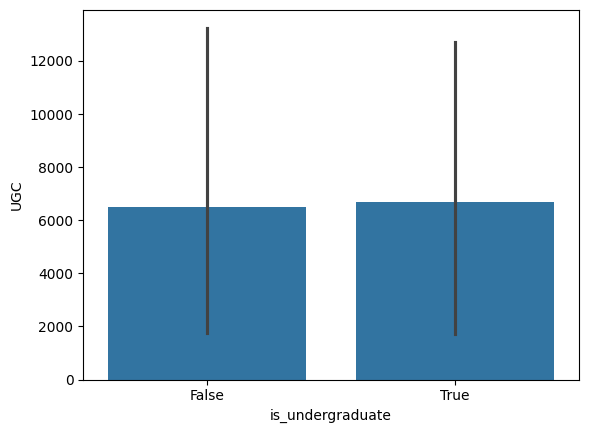

In [59]:
sns.barplot(x=UGS['is_undergraduate'],y=UGS['UGC'])
plt.show()

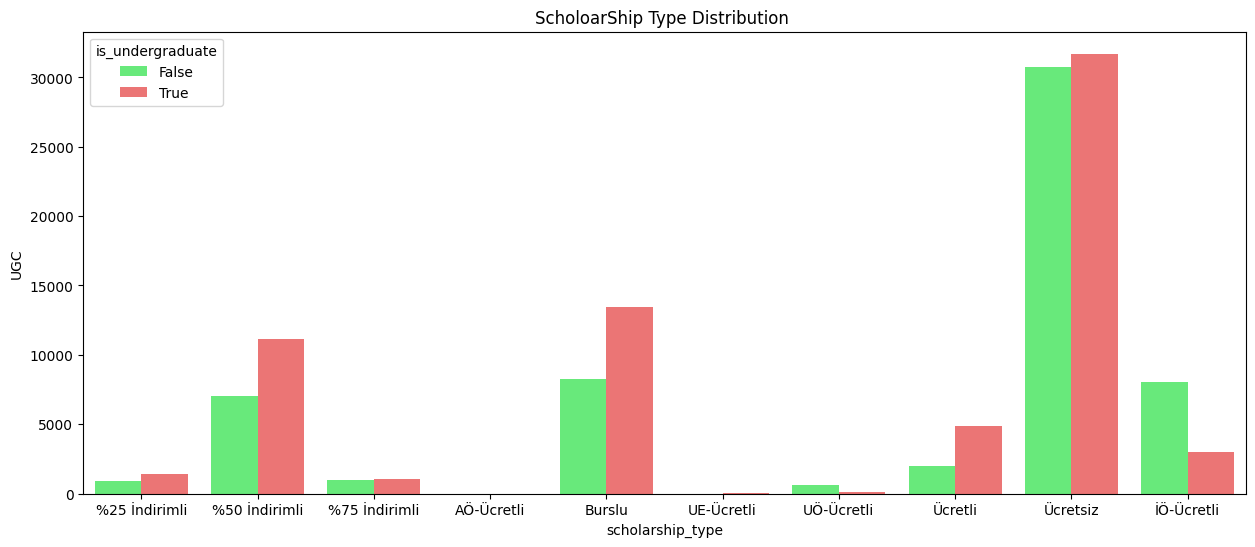

In [60]:
plt.figure(figsize=(15,6))
sns.barplot(x=UGS['scholarship_type'],y=UGS['UGC'],hue=UGS['is_undergraduate'],palette=['#52FF6C','#FF6161'])
plt.title('ScholoarShip Type Distribution ')
plt.show()

# insight 
this is visual to proper understand scholoarship type have how much student is graduate and how much not yet.

### **9. Department wise Quota's**

<Axes: ylabel='total_quota'>

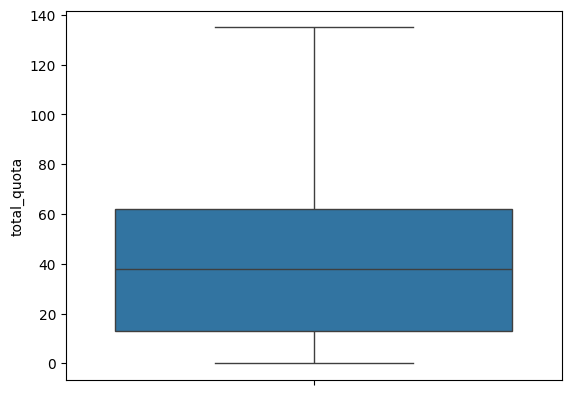

In [61]:
sns.boxplot(df['total_quota'])

In [62]:
AQPD = df.groupby(['department_name'])['total_quota'].mean().rename('QS').reset_index()

In [63]:
AQPD.sort_values(by='QS',ascending=False,inplace=True)

In [64]:
AQPD.head(10)

,department_name,QS
370,Mühendislik ve Doğa Bilimleri Programları,77.285714
7,Aile ve Tüketici Bilimleri,73.166667
149,Elektrik Mühendisliği,70.326087
611,Veterinerlik,69.087805
639,Çalışma Ekonomisi ve Endüstri İlişkileri,68.452055
640,Çay Tarımı ve İşleme Teknolojisi,64.333333
483,Sinoloji,64.090909
11,Alman Dili ve Edebiyatı,63.590909
687,İngiliz Dilbilimi,63.500000
22,Arap Dili ve Edebiyatı,63.287671


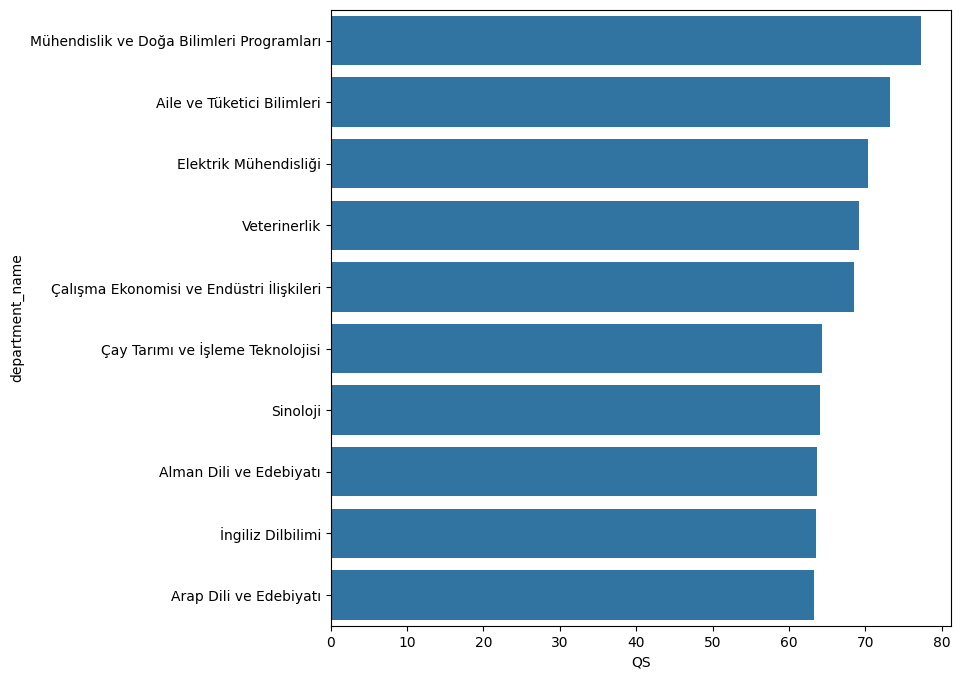

In [65]:
plt.figure(figsize=(8,8))
sns.barplot(y=AQPD['department_name'].head(10),x=AQPD['QS'].head(10))
plt.show()

# insight

here we can see top 10 departments which have maximum demand.

In [ ]:
### Why This Matters
- Universities can prioritize investment in high-demand departments to maximize international enrollment.
- Emerging departments with moderate but growing demand present expansion opportunities.
- Policymakers can align scholarship and visa policies with high-demand academic areas.


## **10. Total Enrolled in each department**

<Axes: ylabel='total_enrolled'>

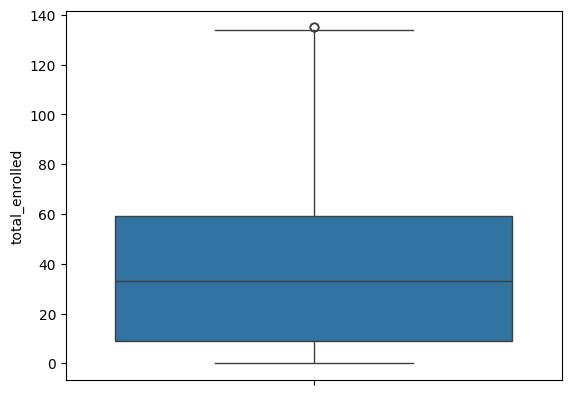

In [66]:
sns.boxplot(df['total_enrolled'])

In [67]:
AEPD = df.groupby(['department_name'])['total_enrolled'].sum().rename('ES').reset_index()
AEPD.sort_values(by = 'ES',ascending=False,inplace=True)

In [68]:
AEPD

,department_name,ES
72,Bilgisayar Programcılığı,104633
657,Çocuk Gelişimi,99897
683,İlk ve Acil Yardım,76740
70,Bilgisayar Mühendisliği,73309
368,Muhasebe ve Vergi Uygulamaları,71400
...,...,...
47,Bahçe Bitkileri Üretimi ve Pazarlaması,0
38,Azerbaycan Dili ve Edebiyatı,0
39,Azerbaycan Dili Öğretmenliği,0
449,Rus Dili Öğretmenliği,0


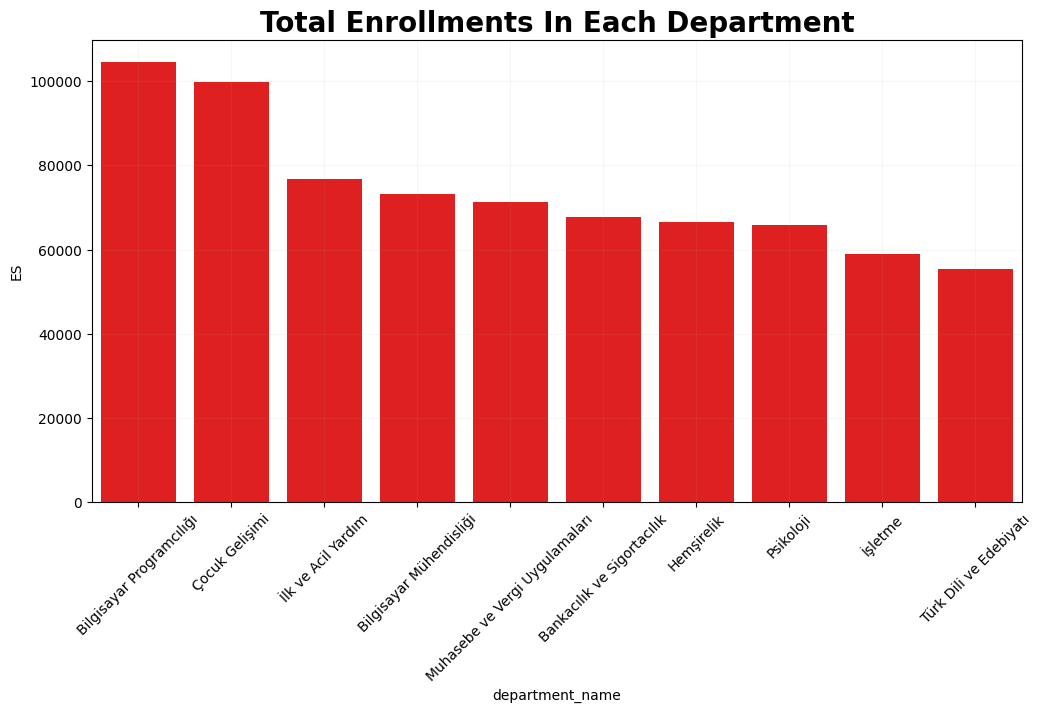

In [69]:
plt.figure(figsize=(12,6))
sns.barplot(x=AEPD['department_name'].head(10),y=AEPD['ES'].head(10),color = 'r')
plt.title('Total Enrollments In Each Department',fontdict={'fontweight':'bold','fontsize':20})
plt.grid(True,alpha=0.10)
plt.xticks(rotation=45)
plt.show()

**Insight 10:**
1. According to the number of quotes per each department for the next admission the quotas needed to be revised according to number of enrollments.

---

## **12. Gender Demographics**

In [71]:
SP = df.groupby(['university_type']).agg(MaleSum=('male','sum'),FemaleSum=('female','sum')).reset_index()

In [72]:
SP['TotalSUm'] = SP['MaleSum']+SP['FemaleSum']

In [73]:
SP

,university_type,MaleSum,FemaleSum,TotalSUm
0,devlet,1670820,1837065,3507885
1,kktc,30959,30325,61284
2,vakif,383996,511897,895893
3,yurt_disi,1851,931,2782


# insight 
here we can show in data set male or female ratio

----

## **13. Uinversity Type and department Wise Initial Placement Rate**

In [74]:
df['initial_placement_rate'].describe()

count    125340.000000
mean         89.313089
std          26.185232
min           0.000000
25%         100.000000
50%         100.000000
75%         100.000000
max         128.600000
Name: initial_placement_rate, dtype: float64

In [75]:
UTNPR = df.groupby(['university_type','department_name']).agg(AVGPR = ('initial_placement_rate','mean'),
                                                                        MEDPR = ('initial_placement_rate','median')).reset_index()


In [76]:
UTNPR.sort_values(by='AVGPR',ascending=False,inplace=True)


In [77]:
UTNPR.head(100)

,university_type,department_name,AVGPR,MEDPR
968,vakif,Kimya,100.866667,100.0
440,devlet,Su Ürünleri Endüstrisi Mühendisliği,100.000000,100.0
22,devlet,Arka-Yüz Yazılım Geliştirme,100.000000,100.0
437,devlet,Su Altı Kaynak Teknolojisi,100.000000,100.0
434,devlet,Spor Bilimleri,100.000000,100.0
...,...,...,...,...
358,devlet,Perfüzyon Teknikleri,100.000000,100.0
344,devlet,Ortez-Protez,100.000000,100.0
955,vakif,Hava Aracı İmalat Teknolojileri,100.000000,100.0
944,vakif,Görsel İletişim,100.000000,100.0


In [78]:
df.head().T

,0,1,2,3,4
program_code,106510077,106510077,106510077,106510077,106510077
year,2019,2020,2021,2022,2023
university_name,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ,ABDULLAH GÜL ÜNİVERSİTESİ
city,KAYSERİ,KAYSERİ,KAYSERİ,KAYSERİ,KAYSERİ
university_type,devlet,devlet,devlet,devlet,devlet
department_name,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği,Bilgisayar Mühendisliği
faculty_name,Mühendislik Fakültesi,Mühendislik Fakültesi,Mühendislik Fakültesi,Mühendislik Fakültesi,Mühendislik Fakültesi
score_type,SAY,SAY,SAY,SAY,SAY
scholarship_type,Ücretsiz,Ücretsiz,Ücretsiz,Ücretsiz,Ücretsiz
is_undergraduate,True,True,True,True,True


# 14. Score type and demand per quota


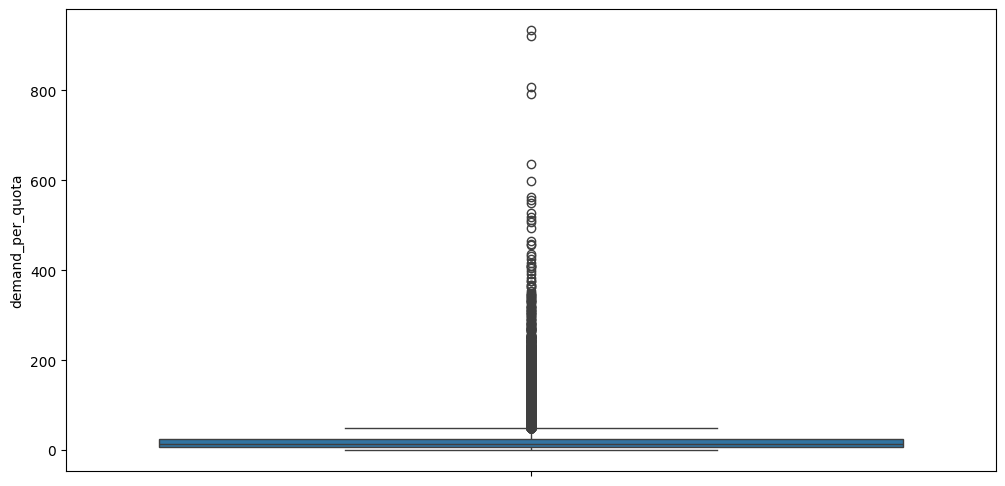

In [82]:
plt.figure(figsize=(12,6))
sns.boxplot(df['demand_per_quota'])
plt.show()

In [86]:
STWDPQ = df.groupby('score_type')['demand_per_quota'].mean().rename('AVG OF QUOTA PER SCORE TYPE').reset_index()

In [87]:
STWDPQ

,score_type,AVG OF QUOTA PER SCORE TYPE
0,DİL,15.719607
1,EA,16.438468
2,SAY,17.933178
3,SÖZ,16.851819
4,TYT,20.488701


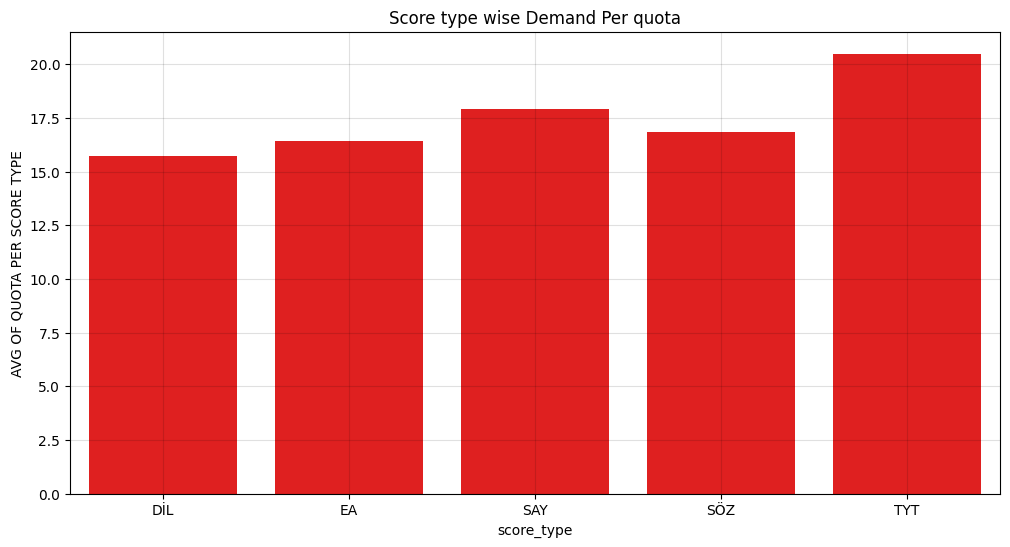

In [103]:
plt.figure(figsize=(12,6))
sns.barplot(x=STWDPQ['score_type'],y=STWDPQ['AVG OF QUOTA PER SCORE TYPE'],color = 'r')
plt.grid(True,alpha = 0.12,color = 'black')
plt.title('Score type wise Demand Per quota')
plt.show()

## insight
here i can try to show sore type waise demand per quota

**Why This Matters**
- Universities can use this trend to plan capacity and international recruitment strategies.
- Policymakers can assess how resilient international education is to global disruptions.
- The gradual recovery suggests stability but highlights the need for diversification in international student sourcing.

## Final Summary & Key Takeaways

### Business & Policy Implications
- Universities can prioritize capacity expansion and marketing efforts in consistently high-demand departments.
- Institutions with lower international enrollment may need stronger global branding or differentiated program offerings.
- Policymakers can use these trends to align scholarship programs and visa policies with high-demand academic areas.
- High concentration among few universities highlights potential risk and the need for diversification.

### Limitations
- The dataset does not include student nationality, which limits geographic demand analysis.
- Admission data alone does not reflect enrollment completion or graduation outcomes.
- External factors such as policy changes or tuition fees are not captured in this dataset.

### Future Scope
- Analyze country-wise demand patterns if nationality data becomes available.
- Combine tuition fee and scholarship data to assess affordability impact.
- Perform predictive analysis to forecast future international admissions.

### Conclusion
This analysis provides a data-driven view of international university admissions in Turkey,
highlighting key trends, concentration patterns, and strategic opportunities 
 for institutions and policymakers.